## Understanding the LSMOD.2 model and the supporting Fortran Programs

The steps involve - 
1. Obtaining the paleomagnetic field data for LSMOD.2 model
2. Reconstruct the geomagnetic field using the LSMOD.2 model
3. Visualize the field intensities as full SH at different ages
4. VIsualize the field intensities with respect to a reference age (48 ka BP)

### What is Paleomagnetic field?
A paleomagnetic field is the ancient magentic field of the Earth preserved in rocks, sediment, or archeological materials at the time they formed. There are mainly two ways in which this data is stored in materials.
1. `Thermoremanent magnetization`: When material containing magentic material are heated above the Curie temperature, the magnetic monet of the particles at atomic level aligns with the geomagnetic field. Upon cooling, these magnetic moments are preserved in oriented samples of such materials, with information about the field intensity and direction. E.g.: ceramics, bricks, volcanic lava flows
2. `Depositional remanence`: In sediments or speleothems, the magentic particles get oriented along the ambient geomagentic field during deposition and stays in that position when further materials gathers and solidies. However, this technique only provides the variation in field intensity, therefore, requires additional dating processes to quantify the field informtaion to the past date. [6]

### LSMOD.2
This is a global spherical harmonic paleomagnetic field model that describes the MF evolution from 50 to 30 ka BP based on existing paleomagnetic sediment records and colcanic data.
- This timeline includes the data from the Lashamps excursion (~41 ka BP) and Mono Lake excursion (~34 ka BP).
- Obtains spherical harmonic MF coefficients for individual epochs
- Obtains time-series of magnetic declination, inclination, and field intensity from 49.95 to 30 ka BP for any location on Earth.

Data Source: [Korte, Monika; Brown, Maxwell (2019): LSMOD.2 - Global paleomagnetic field model for 50 -- 30 ka BP. V. 2. GFZ Data Services](https://doi.org/10.5880/GFZ.2.3.2019.001)

### Reconstructing the Paleomagnetic Field from LSMOD.2

The LSMOD.2 dataset provides *spherical harmonic coefficients* that describe Earth’s magnetic field at different times between 50 and 30 ka BP. To convert these coefficients into actual field values (intensity, declination, inclination) at a specific location and epoch, the provided Fortran routines (`LSfield.f`, `LScoefs.f`) are used. These routines:

1. Read the coefficient file,
2. Interpolate spherical harmonics for the target time,
3. Output magnetic field coordinates in either local or global reference frames.

The resulting field values form the geomagnetic input into subsequent cosmic ray cutoff rigidity and trajectory modelling steps. 

### `LSMOD.2` file

This file contains **time-dependent spherical harmonic Gauss coefficients** ($g_l^m(t),h_l^m(t)$) obtained from --

$$
B(r,\theta,\phi,t) = \sum_{l=1}^{L}\sum_{m=0}^{l}(g_l^m(t)\cos m\phi+h_l^m(t)\sin m\phi)P_l^m(\cos\theta)
$$

$P_l^m$: assocaited legendre functions

$l$: spherical harmonic degree

$m$: order

### `LScoefs.f` file

This program reads LSMOD.2, interpretes the coefficents for a given time, and outputs the Gauss coefficients (spherical harmonic degree l, order m, $g_l^m$, $h_l^m$) at each epoch.

### `LSfield.f` file

This program takes the Gauss coefficients and computes the Declination (D), inclination (I), and the total field intensity (F) at a specifc Age in ka BP.

Following the `installation_in_bash.txt`, the D, I, and F values can be obtained for any location over the years.

## Dynamic Visualization of the Intensity of Magnetic Field

In [6]:
# !pip3 install pandas
# !pip3 install matplotlib

In [7]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import os

In [8]:
# python wrapper for ./lsfield to obtain the F, D, and I values 
# at different ages for a specific location. (arg: latitude and longitude)

from src.run_lsfield import run_lsfield

In [9]:
df = run_lsfield(lat=42.5, lon=12.5)

print(df.head())

   Age_ka  D_deg  I_deg  F_microT
0   49.93  -0.16  61.40      61.4
1   49.91   0.57  60.88      61.1
2   49.89   1.29  60.36      60.8
3   49.87   1.98  59.81      60.4
4   49.85   2.54  59.24      60.0


In [10]:
def plot_field_intensity(df, lat, lon):
    plt.figure(figsize=(10,6))
    plt.plot(df["Age_ka"], df["F_microT"])
    plt.gca().invert_xaxis()  # age decreases toward present
    plt.xlabel("Age (ka BP)")
    plt.ylabel("Magnetic Field Intensity (µT)")
    plt.title(f"Magnetic Field Intensity at Lat={lat}, Lon={lon}")
    plt.grid()
    plt.show()

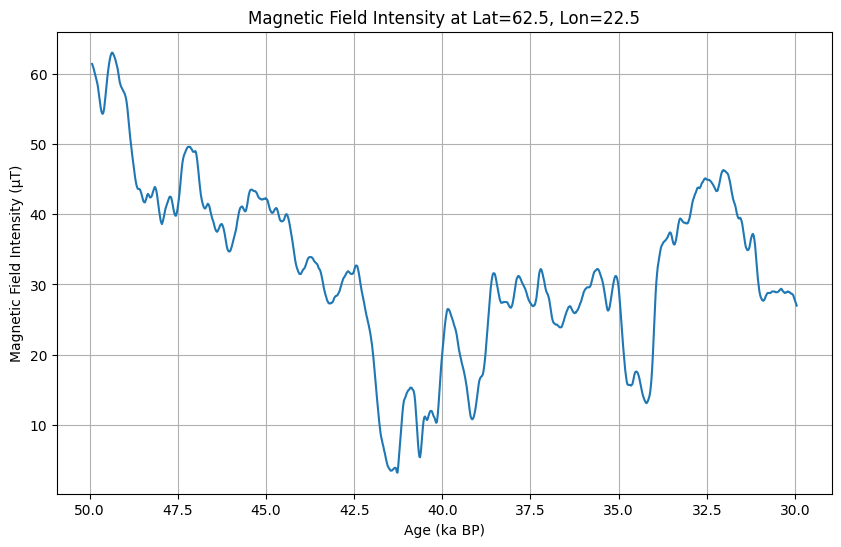

In [11]:
plot_field_intensity(df, 62.5, 22.5)

In [25]:
# !pip3 install ipywidgets

## Field Intensity using Dipole Approximation

The magnetic field of a dipole moment $\vec{m}$ at position $\vec{r}$ is --
$$
\mathbb{B}(r) = \frac{\mu_0}{4\pi r^3}[3(\vec{m}\cdot\hat{r})\hat{r}-\vec{m}]
$$

where, $\vec{m}$: dipole moment vector,

r: radial distance from center of dipole

$\hat{r}$: radial unit vector

For Earth, the scalar dipole moment (M) is time-dependent and along the vertical z-axis.
$$
\implies \mathbb{m}(t) = M(t)\hat{z}
$$

***Applicable only for dipole approximations***

From LSMOD.2, the coefficients $g_1^0, g_1^1, h_1^1$ are extracted. These are the **spherical harmonic terms of degree-1.**

$$
M(t)=\sqrt{{g_1^0}^2+{g_1^1}^2+{h_1^1}^2}
$$

The dipole field components in spherical coordinates are --
$$
B_r = \frac{2M(t)}{r^3}\cos\theta \\
\, \\
B_{\theta} = \frac{M(t)}{r^3}\sin\theta \\
\, \\
B_{phi} = 0
$$
Where, $\theta$ is the colatitude (angle from north pole)


The total field magnitude is given by --
$$
\mathbb{F} = \sqrt{B_r^2+B_{\theta}^2} \\ 
\,\\
\implies \mathbb{F} = \sqrt{(\frac{2M(t)}{r^3}\cos\theta)^2+(\frac{M(t)}{r^3}\sin\theta)^2} \\
\,\\
\therefore \mathbb{F} =\frac{M(t)}{r^3}\sqrt{1+3\cos^2\theta} \\
\,\\
\text{But the geomagnetic latitude, }\lambda = 90-\theta \\
\, \\
\implies \mathbb{F} = \frac{M(t)}{r^3}\sqrt{1+3\sin^2\lambda}
$$



### Pre-compute the dipole values for visualization

Before computing the dipole, it is important to understand the coefficient data in the `LSMOD.2` file. The first two lines in the data provides the metadata about the model.

- The age starts from 48 ka BP to 28 ka BP
-       10  0   403
    This represents 
    1) Maximum spherical harmonic degree 
    2) Minimum spherical harmonic degree, and 
    3) Number of spline basis functions

- Given that $L_{max} = 10$, implies the range of $l$ is: $1\le l \le L_{max}=10$
- Degree 1 -> dipole; Degree 2 -> Quadrapole, etc.
- Here, $l$ starts at 1, implying that monopoles do not exist.
- The number of epochs = 403. This implies that there are 403 steps between 48000 and 28000
$$
48000 - 28000 = 20000 \\
\implies \text{ Interval, }\Delta{t} = \frac{20000}{403-1} \\
\Delta{t} \approx 50 years\text{ (from metadata)}
$$

From the magnetic field equation, 

$$
B(r,\theta,\phi,t) = \sum_{l=1}^{L}\sum_{m=0}^{l}(g_l^m(t)\cos m\phi+h_l^m(t)\sin m\phi)P_l^m(\cos\theta)
$$

The following can be inferred --
1. For each degree $l$, 
    - One $g_l^m$ coefficient for every $m=0,...,l$. i.e., $l+1$ coefficients
    - One $h_l^m$ coefficient for every $m=1,...,l$. this is because, there is no $h_l^0$ term as $\sin0 = 0$. i.e., $l$ coefficients.

2. Therefore, each spherical harmonic degree, $l$ contributes to $(2l+1)$ coefficients.
3. Total number of coefficients across $l=1 \to L$ is given by --
$$
N = \sum^L_{i=1}(2l+1) \\
\, \\
\text{simplies to }N = L(L+2)
$$

Given, $L=10 \implies N = 120$. Therefore, there are 120 coefficients per epoch.

Given there are 403 epochs, there are a total of $403 \times 120 = 48360$ coefficeints in the LSMOD.2 data.

In [13]:
import numpy as np

`LSMOD.2` contains the spline control points, 
$$
N_{spline} = \text{NumEpochs} + k \\
N_{spline} = 403 + 4 \\
N_{spline}= 407
$$

k = 4 for cubic splines and the coefficients $(403 \times 120 = 48350)$.

In [14]:
file_path = "data/LSMOD2/LSMOD2/LSMOD.2"

with open(file_path, "r") as file:
    lines = file.readlines()

#strip the whitespaces
lines = [line.strip() for line in lines]

# gather the necessary metadta from line 2
Lmax, Lmin, points = map(int, lines[1].split())

print("Lmax:", Lmax)
print("Epochs:", points)

Lmax: 10
Epochs: 403


In [15]:
steps = np.array(list(map(float, lines[2].split())))
print(f"Number of spline control points: {len(steps)}")

Number of spline control points: 407


In [16]:
coeffs = np.array(list(map(float, lines[3].split())))
print(f"Number of spline Coefficients: {len(coeffs)}")

Number of spline Coefficients: 48360


In [17]:
print(f"The start knot: {steps[0]}")
print(f"The end knot: {steps[-1]}")

The start knot: -48150.0
The end knot: -27850.0


The number of spline control points = 407. This implies that there are 407 control points between 48150 and 27850
$$
48150 - 27850 = 20300 \\
\implies \text{ Interval, }\Delta{t} = \frac{20300}{407-1} \\
\Delta{t} = 50 years\text{ (This is verified from actual LSMOD.2 data)}
$$

In [18]:
locations = {
    "North Pole": {90,0},
    "Arctic Circle": (66.5, 60),
    "Tropic of Cancer": (23.5, 120),
    "Equator": (0,180),
    "Tropic of Capricorn": (-23.5,-120),
    "Antarctic Circle": (-66.5,-60)
}

In [19]:
loc_data = {}

for name, (lat,lon) in locations.items():
    print(f"Loading {name}...")
    loc_data[name] = run_lsfield(lat, lon)

Loading North Pole...
Loading Arctic Circle...
Loading Tropic of Cancer...
Loading Equator...
Loading Tropic of Capricorn...
Loading Antarctic Circle...


In [20]:
loc_data

{'North Pole':      Age_ka  D_deg  I_deg  F_microT
 0     49.93  -2.02   0.51      33.9
 1     49.91  -2.08   1.09      34.1
 2     49.89  -2.17   1.63      34.2
 3     49.87  -2.30   2.07      34.4
 4     49.85  -2.46   2.36      34.4
 ..      ...    ...    ...       ...
 995   30.03   6.29 -28.48      20.8
 996   30.01   7.24 -29.67      20.9
 997   29.99   8.29 -30.83      21.1
 998   29.97   9.38 -31.97      21.3
 999   29.95  10.48 -33.07      21.5
 
 [1000 rows x 4 columns],
 'Arctic Circle':      Age_ka  D_deg  I_deg  F_microT
 0     49.93 -22.31  79.19      73.4
 1     49.91 -20.94  79.43      73.8
 2     49.89 -19.52  79.65      74.1
 3     49.87 -18.11  79.86      74.3
 4     49.85 -16.87  79.99      74.5
 ..      ...    ...    ...       ...
 995   30.03   8.20  68.50      42.4
 996   30.01   7.18  67.61      41.7
 997   29.99   6.32  66.65      41.0
 998   29.97   5.55  65.64      40.3
 999   29.95   4.83  64.58      39.6
 
 [1000 rows x 4 columns],
 'Tropic of Cancer':     

In [21]:
def plot_field_at_age(target_age):
    plt.figure(figsize=(8,6))

    for name, df in loc_data.items():
        F_interp = np.interp(
            target_age,
            df["Age_ka"][::-1],
            df["F_microT"][::-1]
        )
        plt.scatter(name, F_interp)

    plt.ylabel("Magnetic Field Intensity (micro Tesla)")
    plt.title(f"Magentic Field at {target_age:.2f} ka BP (Major Latitudes)")
    plt.xticks(rotation =45)
    plt.grid()
    plt.show()

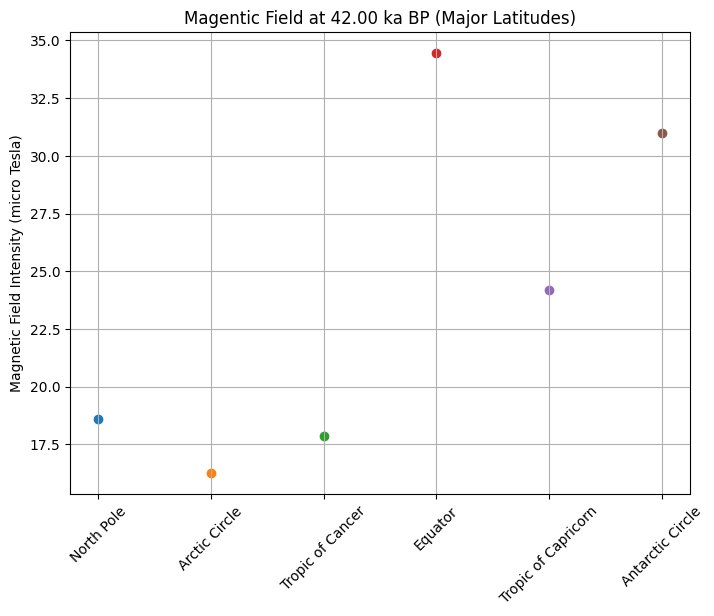

In [22]:
plot_field_at_age(42)

In [ ]:
from ipywidgets import interact

interact(plot_field_at_age, target_age=(28.0, 48.0, 0.1));

In [ ]:
def latitude_profile(target_age):
    lats = np.linspace(-90, 90, 37)
    intensities = []

    for lat in lats:
        df = run_lsfield(lat, 0)
        F_interp = np.interp(
            target_age,
            df["Age_ka"][::-1],
            df["F_microT"][::-1]
        )
        intensities.append(F_interp)

    plt.figure(figsize=(8,6))
    plt.plot(lats, intensities)
    plt.xlabel("Latitude")
    plt.ylabel("Field Intensity (μT)")
    plt.title(f"Latitude Profile at {target_age} ka BP")
    plt.grid()
    plt.show()

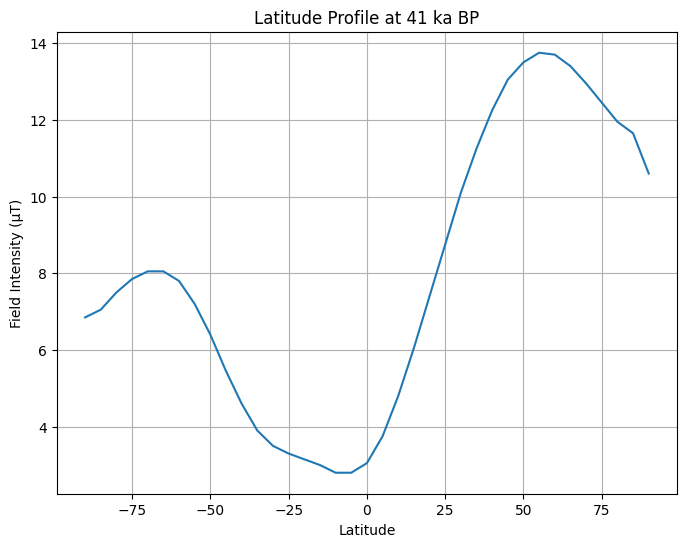

In [ ]:
latitude_profile(41)

In [ ]:
# Define latitude grid
latitudes = np.linspace(-90, 90, 37)

latitude_data = {}

for lat in latitudes:
    print(f"Loading latitude {lat:.1f}")
    df = run_lsfield(lat, 0)  # longitude fixed at 0
    latitude_data[lat] = df

Loading latitude -90.0
Loading latitude -85.0
Loading latitude -80.0
Loading latitude -75.0
Loading latitude -70.0
Loading latitude -65.0
Loading latitude -60.0
Loading latitude -55.0
Loading latitude -50.0
Loading latitude -45.0
Loading latitude -40.0
Loading latitude -35.0
Loading latitude -30.0
Loading latitude -25.0
Loading latitude -20.0
Loading latitude -15.0
Loading latitude -10.0
Loading latitude -5.0
Loading latitude 0.0
Loading latitude 5.0
Loading latitude 10.0
Loading latitude 15.0
Loading latitude 20.0
Loading latitude 25.0
Loading latitude 30.0
Loading latitude 35.0
Loading latitude 40.0
Loading latitude 45.0
Loading latitude 50.0
Loading latitude 55.0
Loading latitude 60.0
Loading latitude 65.0
Loading latitude 70.0
Loading latitude 75.0
Loading latitude 80.0
Loading latitude 85.0
Loading latitude 90.0


In [ ]:
# Find approximate minimum dipole year at different latitudes

def min_field(lat):
    min_df = latitude_data[lat]
    min_index = min_df["F_microT"].idxmin()
    min_age = min_df["Age_ka"].iloc[min_index]
    print("Minimum near:", min_age, "ka BP at latitude",lat)

min_field(0.0)
min_field(25.0)
min_field(65.0)
min_field(90.0)
min_field(-25.0)
min_field(-65.0)
min_field(-90.0)

Minimum near: 40.99 ka BP at latitude 0.0
Minimum near: 40.65 ka BP at latitude 25.0
Minimum near: 41.37 ka BP at latitude 65.0
Minimum near: 41.31 ka BP at latitude 90.0
Minimum near: 40.51 ka BP at latitude -25.0
Minimum near: 40.47 ka BP at latitude -65.0
Minimum near: 40.59 ka BP at latitude -90.0


In [ ]:
def latitude_profile_multiple(years):
    plt.figure(figsize=(9,6))

    for target_age in years:
        intensities = []

        for lat in latitudes:
            df = latitude_data[lat]
            F_interp = np.interp(
                target_age,
                df["Age_ka"][::-1],
                df["F_microT"][::-1]
            )
            intensities.append(F_interp)

        plt.plot(latitudes, intensities, label=f"{target_age} ka")

    plt.xlabel("Latitude (deg)")
    plt.ylabel("Magnetic Field Intensity (μT)")
    plt.title("Latitude Profiles of Magnetic Field Intensity")
    plt.legend()
    plt.grid()
    plt.show()

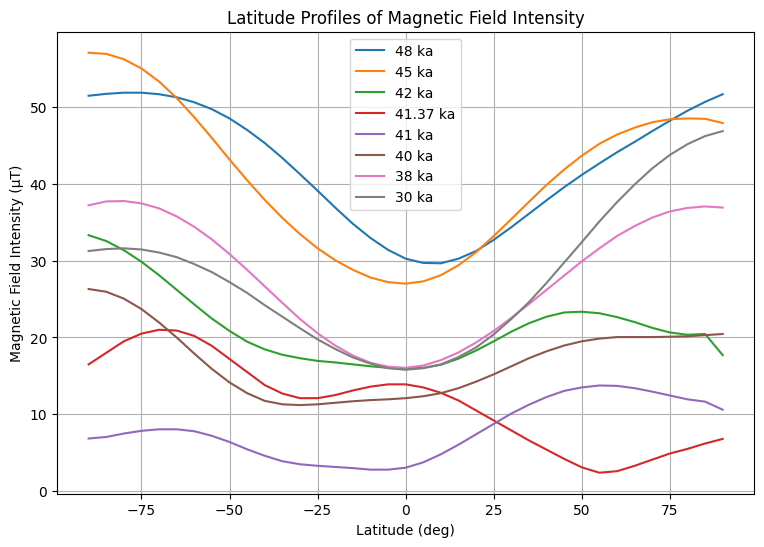

In [ ]:
latitude_profile_multiple([48, 45, 42, 41.37, 41, 40, 38, 30])

### Observation

At normal dipole state, the field is a function of $\lambda$ as defined before --
$$
F(\lambda) \propto \sqrt{1+3\sin^2\lambda}
$$


`Pre- and Post- Laschamps era` --

- Strong at poles
- Weak at equator
- Smooth symmetric curve

`Near Laschamps era` (41ka BP) --

- Overall intensity drops
- Dipole component weakens
- Profile flattens
- Asymmetry prominent

## Normalized Magnetic Field with a Reference Field (comparable to present-day field)

The LSMOD.2 can be used to derive normalized Magnetic Field Intensity for its entire range for comparison. Here, 48 ka BP is considered as the reference F

In [ ]:
reference_age = 48.0 #ka BP

In [ ]:
def latitude_profile_normalized(years, reference_age = 48.0):
    plt.figure(figsize = (9,6))

    reference_profile = []
    for lat in latitudes:
        df = latitude_data[lat]
        F_ref = np.interp(
            reference_age,
            df["Age_ka"][::-1],
            df["F_microT"][::-1]
        )
        reference_profile.append(F_ref)

    reference_profile = np.array(reference_profile)

    # Plot each year
    for target_age in years:
        intensities = []
        for lat in latitudes:
            df = latitude_data[lat]
            F_interp = np.interp(
                target_age,
                df["Age_ka"][::-1],
                df["F_microT"][::-1]
            )
            intensities.append(F_interp)

        intensities = np.array(intensities)

        normalized = intensities/reference_profile

        plt.plot(latitudes, normalized, label=f"{target_age} ka")

    plt.axhline(1.0, linestyle="--")
    plt.xlabel("Latitude (deg)")
    plt.ylabel("Normalized Field Strength")
    plt.title(f"Relative Magentic Field Weakening (Ref = {reference_age} ka)")
    plt.legend()
    plt.grid()
    plt.show()


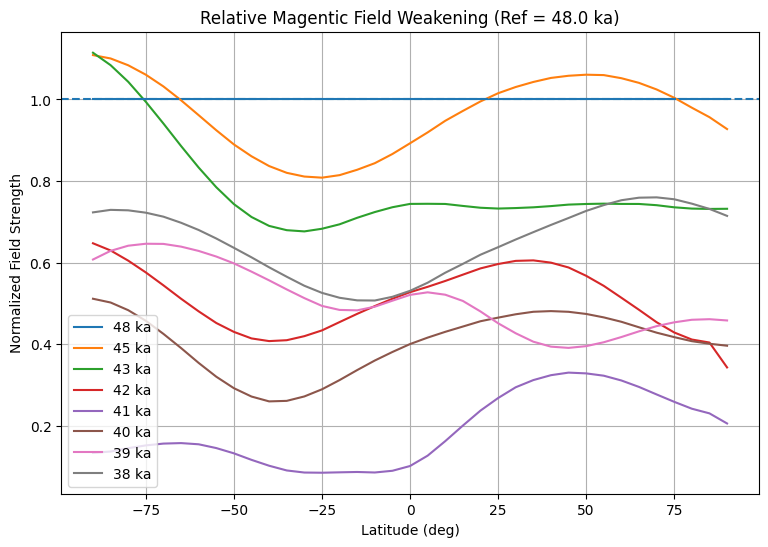

In [ ]:
# Laschamps Excursion (41 ka BP)
latitude_profile_normalized([48, 45, 43, 42, 41, 40, 39, 38])

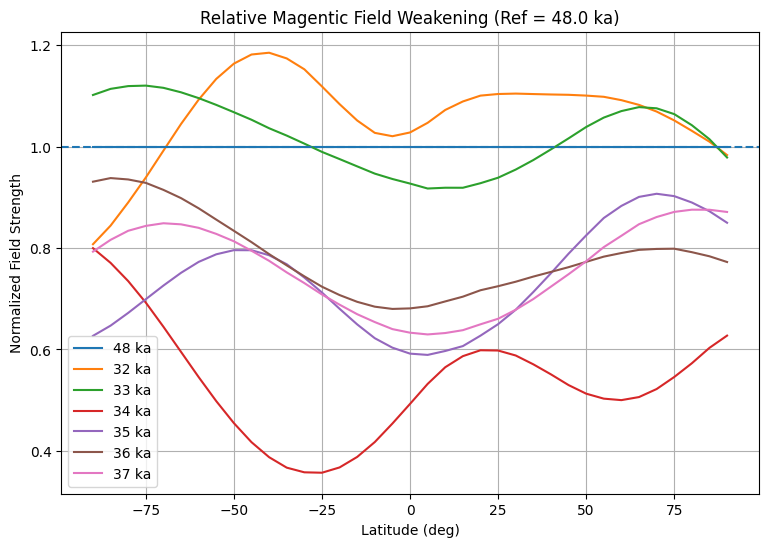

In [ ]:
# Mono Lake Excursion (34 ka BP)
latitude_profile_normalized([48, 32, 33, 34, 35, 36, 37])

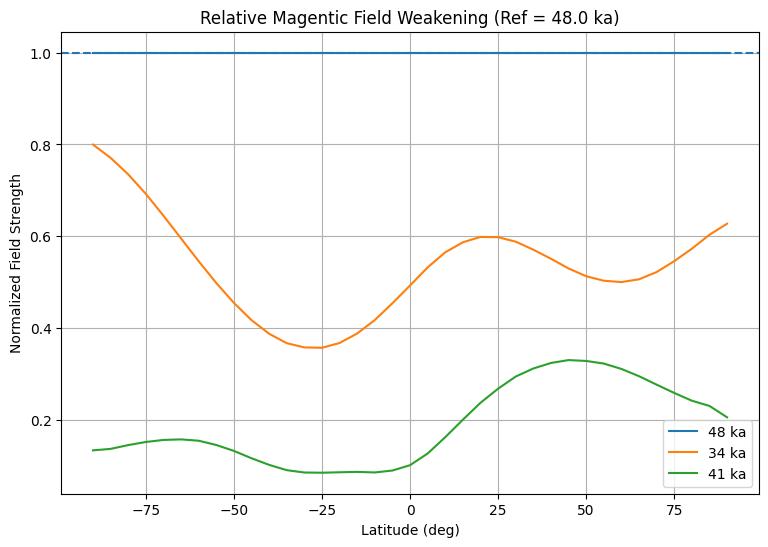

In [ ]:
# Comparing Mono Lake and Laschamps
latitude_profile_normalized([48, 34, 41])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

equator_df = latitude_data[0]

def get_strength_ratio(age):
    M_now = np.interp(
        age,
        equator_df["Age_ka"][::-1],
        equator_df["F_microT"][::-1]
    )
    M_ref = np.interp(
        48.0,
        equator_df["Age_ka"][::-1],
        equator_df["F_microT"][::-1]
    )
    return M_now / M_ref

def plot_earth_field(age):
    ratio = get_strength_ratio(age)

    fig, ax = plt.subplots(figsize=(8,8))

    earth = plt.Circle((0,0), 1, color='lightblue')
    ax.add_artist(earth)

    theta = np.linspace(0.01, np.pi-0.01, 400)

    # Change number of field lines based on strength
    num_lines = int(4 + 12 * ratio)
    L_values = np.linspace(1.2, 4, num_lines)

    for L in L_values:
        r = L * (np.sin(theta))**2
        x = r * np.sin(theta)
        y = r * np.cos(theta)

        ax.plot(x, y, color='darkblue', linewidth=1)
        ax.plot(-x, y, color='darkblue', linewidth=1)

    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)
    ax.set_aspect('equal')
    ax.set_title(f"Magnetic Field at {age:.2f} ka BP\n"
                 f"Relative Strength: {ratio:.2f}")
    ax.grid()
    plt.show()

interact(plot_earth_field, age=(28.0, 48.0, 0.1))

interactive(children=(FloatSlider(value=38.0, description='age', max=48.0, min=28.0), Output()), _dom_classes=…

<function __main__.plot_earth_field(age)>

### Visualization WITHOUT Dipole Approximation

- Implements the spline-evaluated coefficients using `ls_coefs`
- Uses the complete spherical harmonics (all 120 coefficients)
- Include dipole and non-dipole MF

In [ ]:
spline_coeffs = coeffs.reshape((403,120)) # initially it is of shape (48360,)
spline_coeffs

array([[-2.97686613e+04, -3.68811870e+03,  8.38578344e+01, ...,
        -2.81248523e-02,  9.36365028e-03,  2.37732009e-03],
       [-3.03055488e+04, -3.38032167e+03, -2.32012415e+01, ...,
        -1.57491123e-02,  6.02433252e-03,  9.09041776e-04],
       [-3.09078889e+04, -3.00237416e+03, -1.18954592e+02, ...,
        -4.05944219e-03,  2.61257634e-03, -5.84408204e-04],
       ...,
       [-1.78690160e+04,  1.66838607e+03,  3.11775145e+03, ...,
         8.28286052e-03, -1.92134495e-02, -1.27598244e-02],
       [-1.71739394e+04,  2.38452038e+03,  4.03808574e+03, ...,
         6.64351933e-03, -2.28065255e-02, -1.34189433e-02],
       [-1.64441076e+04,  3.07891726e+03,  4.93087002e+03, ...,
         4.86879249e-03, -2.64945231e-02, -1.39628017e-02]],
      shape=(403, 120))

In [ ]:
# A python wrapper to run the ./lscoefs program to obtain the SH coefficients at a certain age

from src.lscoefs import get_coeffs_at_age

In [ ]:
coeff_vec = get_coeffs_at_age(41.0)
print(coeff_vec.shape)

(120,)


In [ ]:
!pip3 install scipy

In [ ]:
from scipy.special import lpmv # to compute associated Legendre function

In [ ]:
def compute_field(coeff_vec, r, theta, phi, Lmax=10):
    
    """
    This function computes the associated Legendre functions using lpmv function
    """
    
    Br = np.zeros_like(theta)
    Btheta = np.zeros_like(theta)
    Bphi = np.zeros_like(theta)
    
    idx = 0
    
    for l in range(1, Lmax+1):
        for m in range(0, l+1):
            
            g = coeff_vec[idx]
            idx += 1
            
            if m == 0:
                h = 0
            else:
                h = coeff_vec[idx]
                idx += 1
            
            P = lpmv(m, l, np.cos(theta))
            
            cos_mphi = np.cos(m*phi)
            sin_mphi = np.sin(m*phi)
            
            common = g*cos_mphi + h*sin_mphi
            
            factor = r**(-(l+2))
            
            Br -= (l+1)*factor*common*P
            
            # Derivative w.r.t theta
            dP = np.gradient(P, theta[0,:], axis=1)
            Btheta += factor*common*dP
            
            if m != 0:
                Bphi += factor*(m/np.sin(theta))*(h*cos_mphi - g*sin_mphi)*P
    
    return Br, Btheta, Bphi

In [ ]:
def spherical_to_cartesian(Br, Btheta, Bphi, theta, phi):
    
    Bx = (Br*np.sin(theta)*np.cos(phi) +
          Btheta*np.cos(theta)*np.cos(phi) -
          Bphi*np.sin(phi))
    
    By = (Br*np.sin(theta)*np.sin(phi) +
          Btheta*np.cos(theta)*np.sin(phi) +
          Bphi*np.cos(phi))
    
    Bz = (Br*np.cos(theta) -
          Btheta*np.sin(theta))
    
    return Bx, By, Bz

In [ ]:
!pip3 install plotly
!pip3 install nbformat

In [ ]:
# import plotly.io as pio
# pio.renderers.default = "browser"
import plotly.graph_objects as go
from ipywidgets import interact

In [ ]:
# Reference coefficients at 48 ka
coeff_ref = get_coeffs_at_age(48.0)

def compute_field_magnitude(coeff_vec, r, theta, phi):
    Br, Btheta, Bphi = compute_field(coeff_vec, r, theta, phi)
    Bx, By, Bz = spherical_to_cartesian(
        Br, Btheta, Bphi, theta, phi
    )
    return np.sqrt(Bx**2 + By**2 + Bz**2), Bx, By, Bz


def get_magnetic_pole(coeff_vec):
    g10 = coeff_vec[0]
    g11 = coeff_vec[1]
    h11 = coeff_vec[2]

    m = np.array([g11, h11, g10])
    m = m / np.linalg.norm(m)

    return m


def plot_3d_field(age):

    coeff_vec = get_coeffs_at_age(age)

    theta = np.linspace(0.2, np.pi-0.2, 20)
    phi = np.linspace(0, 2*np.pi, 40)
    theta_grid, phi_grid = np.meshgrid(theta, phi)

    r = 1.2

    # Compute field magnitude at current and reference
    Bmag, Bx, By, Bz = compute_field_magnitude(
        coeff_vec, r, theta_grid, phi_grid
    )

    Bmag_ref, _, _, _ = compute_field_magnitude(
        coeff_ref, r, theta_grid, phi_grid
    )

    Bmag_norm = Bmag / Bmag_ref

    # Convert positions
    x = r*np.sin(theta_grid)*np.cos(phi_grid)
    y = r*np.sin(theta_grid)*np.sin(phi_grid)
    z = r*np.cos(theta_grid)

    fig = go.Figure()

    # Earth sphere
    et, ep = np.meshgrid(
        np.linspace(0,np.pi,40),
        np.linspace(0,2*np.pi,80)
    )

    ex = np.sin(et)*np.cos(ep)
    ey = np.sin(et)*np.sin(ep)
    ez = np.cos(et)

    fig.add_trace(go.Surface(
        x=ex, y=ey, z=ez,
        colorscale='Blues',
        opacity=0.5,
        showscale=False
    ))

    # Normalize field vectors
    Bx_norm = Bx / Bmag_ref
    By_norm = By / Bmag_ref
    Bz_norm = Bz / Bmag_ref

    fig.add_trace(go.Cone(
        x=x.flatten(),
        y=y.flatten(),
        z=z.flatten(),
        u=Bx_norm.flatten(),
        v=By_norm.flatten(),
        w=Bz_norm.flatten(),
        sizemode="scaled",
        sizeref=0.75,
        colorscale="Inferno",
        showscale=True,
        colorbar=dict(title="B / B_ref")
    ))

    # Magnetic pole
    pole = get_magnetic_pole(coeff_vec)

    fig.add_trace(go.Scatter3d(
        x=[pole[0]],
        y=[pole[1]],
        z=[pole[2]],
        mode='markers',
        marker=dict(size=8, color='cyan'),
        name="Magnetic Pole"
    ))

    fig.update_layout(
        title=f"Normalized Geomagnetic Field at {age:.2f} ka BP",
        scene=dict(aspectmode='data')
    )

    fig.show()


interact(plot_3d_field, age=(28.0,48.0,0.5))

interactive(children=(FloatSlider(value=38.0, description='age', max=48.0, min=28.0, step=0.5), Output()), _do…

<function __main__.plot_3d_field(age)>